## Applied Machine Learning Homework 2
### Shane Wang tsw2134

#### Note: all discussions will be in the report. 

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn xgboost

### 1. Data Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import learning_curve, validation_curve

We will be using the Home Credit Default Risk Dataset, found on https://www.kaggle.com/c/home-credit-default-risk, for this assignment.

In [3]:
df = pd.read_csv('home-credit-default-risk/application_train.csv')
df.shape

(307511, 122)

In [4]:
df.head(15)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.000,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.000,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.000,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.000,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


#### Splitting Train, Validation, and Test Sets

In [5]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# First split: 70% Train, 30% Temp (which will be Val + Test)
# df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: Split the 30% Temp into two equal 15% halves
# df_validation, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [6]:
# df_train["TARGET"].value_counts(normalize=True) # see if the train, validation, and test sets are approx. equally split for randomness
y_train.value_counts(normalize=True)

TARGET
0    0.919111
1    0.080889
Name: proportion, dtype: float64

In [7]:
# df_validation["TARGET"].value_counts(normalize=True)
y_validation.value_counts(normalize=True)

TARGET
0    0.920242
1    0.079758
Name: proportion, dtype: float64

In [8]:
# df_test["TARGET"].value_counts(normalize=True)
y_test.value_counts(normalize=True)

TARGET
0    0.91905
1    0.08095
Name: proportion, dtype: float64

#### Dropping Columns with A Lot of Nulls

In [9]:
# Find numerical and categorical columns from training set; Claude helped with this, as this wasn't intuitive
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features:     {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"\nCategorical columns: {cat_cols}")

Numeric features:     104
Categorical features: 16

Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


/var/folders/5z/mlflw5dd4k71m06j1vl7bhxh0000gn/T/ipykernel_74285/1521556572.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [10]:
# Inspect missing values in the training set only
train_missing = X_train.isnull().sum()
train_missing_pct = (train_missing / len(X_train) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': train_missing,
    'Missing %': train_missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Features with missing values: {len(missing_summary)}")
print(missing_summary.head(30).to_string())

Features with missing values: 67
                          Missing Count  Missing %
COMMONAREA_MEDI                  150377      69.86
COMMONAREA_AVG                   150377      69.86
COMMONAREA_MODE                  150377      69.86
NONLIVINGAPARTMENTS_MEDI         149407      69.41
NONLIVINGAPARTMENTS_MODE         149407      69.41
NONLIVINGAPARTMENTS_AVG          149407      69.41
FONDKAPREMONT_MODE               147183      68.38
LIVINGAPARTMENTS_MODE            147079      68.33
LIVINGAPARTMENTS_MEDI            147079      68.33
LIVINGAPARTMENTS_AVG             147079      68.33
FLOORSMIN_MODE                   145996      67.82
FLOORSMIN_MEDI                   145996      67.82
FLOORSMIN_AVG                    145996      67.82
YEARS_BUILD_MODE                 143139      66.50
YEARS_BUILD_MEDI                 143139      66.50
YEARS_BUILD_AVG                  143139      66.50
OWN_CAR_AGE                      141836      65.89
LANDAREA_AVG                     127807      59.3

In [11]:
# Drop columns with >60% missing in the training set (too sparse to impute reliably)
high_missing_thresh = 60.0
high_missing_cols = missing_summary[missing_summary['Missing %'] > high_missing_thresh].index.tolist()
print(f"Dropping {len(high_missing_cols)} columns with >{high_missing_thresh}% missing:")
print(high_missing_cols)

X_train = X_train.drop(columns=high_missing_cols)
X_validation = X_validation.drop(columns=high_missing_cols)
X_test  = X_test.drop(columns=high_missing_cols)

# Refresh column lists after dropping
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining features: {X_train.shape[1]}  (numeric: {len(num_cols)}, categorical: {len(cat_cols)})")

Dropping 17 columns with >60.0% missing:
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE']

Remaining features: 103  (numeric: 88, categorical: 15)


/var/folders/5z/mlflw5dd4k71m06j1vl7bhxh0000gn/T/ipykernel_74285/3712796539.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [12]:
# Refresh the missing count again (after dropping)
train_missing = X_train.isnull().sum()
train_missing_pct = (train_missing / len(X_train) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': train_missing,
    'Missing %': train_missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Features with missing values: {len(missing_summary)}")
print(missing_summary.head(30).to_string())

Features with missing values: 50
                              Missing Count  Missing %
LANDAREA_AVG                         127807      59.37
LANDAREA_MEDI                        127807      59.37
LANDAREA_MODE                        127807      59.37
BASEMENTAREA_MODE                    125984      58.53
BASEMENTAREA_AVG                     125984      58.53
BASEMENTAREA_MEDI                    125984      58.53
EXT_SOURCE_1                         121249      56.33
NONLIVINGAREA_MODE                   118888      55.23
NONLIVINGAREA_AVG                    118888      55.23
NONLIVINGAREA_MEDI                   118888      55.23
ELEVATORS_MEDI                       114721      53.29
ELEVATORS_AVG                        114721      53.29
ELEVATORS_MODE                       114721      53.29
WALLSMATERIAL_MODE                   109480      50.86
APARTMENTS_MEDI                      109300      50.78
APARTMENTS_MODE                      109300      50.78
APARTMENTS_AVG                  

#### Fixing Inconsistent Data Types

In [13]:
df[['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION']].head(10)

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION
0,-9461,-637,-3648.0
1,-16765,-1188,-1186.0
2,-19046,-225,-4260.0
3,-19005,-3039,-9833.0
4,-19932,-3038,-4311.0
5,-16941,-1588,-4970.0
6,-13778,-3130,-1213.0
7,-18850,-449,-4597.0
8,-20099,365243,-7427.0
9,-14469,-2019,-14437.0


In [14]:
# DAYS_* columns are stored as negative integers (days before application).
# Convert to positive absolute values so they read naturally as durations.
# Claude helped me here, since it would've taken me a long time on StackOverflow or something to find out how to filter all columns that contain 'DAYS' in the string name
days_cols = [c for c in num_cols if 'DAYS' in c]
print(len(days_cols))

for col in days_cols:
    X_train[col] = X_train[col].abs()
    X_validation[col] = X_validation[col].abs()
    X_test[col] = X_test[col].abs()

# DAYS_EMPLOYED = 365243 means "unemployed", so replace with NaN so it doesn't inflate employment duration to 1000 years.
if 'DAYS_EMPLOYED' in num_cols:
    sentinel = 365243
    for split in [X_train, X_validation, X_test]:
        split['DAYS_EMPLOYED'] = split['DAYS_EMPLOYED'].replace(sentinel, np.nan)

5


#### Feature Engineering

In [15]:
# Claude helped give me suggestions for which features are necessary
def add_features(df):
    df = df.copy()
    # Credit-to-income burden: how many years of income does the loan represent?
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    # Annual payment burden as share of income
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    # Implicit loan term in years (credit / annuity)
    df['CREDIT_TERM'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
    # Goods price relative to loan amount
    df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
    # Age in years
    df['AGE_YEARS'] = df['DAYS_BIRTH'] / 365.0
    # Employment tenure in years
    df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / 365.0
    # Age group buckets
    df['AGE_GROUP'] = pd.cut(
        df['AGE_YEARS'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=[0, 1, 2, 3, 4]  # encoded as int to avoid object dtype
    ).astype(float)
    return df

In [16]:
X_train = add_features(X_train)
X_validation = add_features(X_validation)
X_test = add_features(X_test)

# Refresh numeric and categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features:     {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"\nCategorical columns: {cat_cols}")

Numeric features:     95
Categorical features: 15

Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


/var/folders/5z/mlflw5dd4k71m06j1vl7bhxh0000gn/T/ipykernel_74285/4281486254.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


#### Missing Value Imputation

In [17]:
from sklearn.impute import SimpleImputer
# Claude taught me how to use sklearn's SimpleImputer

# I am fitting only on training data, then transform validation and test sets with same statistics to avoid data leakage

# Numeric: median imputation (great for incomes, since it's exponential for long tail) 
# - I am NOT doing group-wise medians because that would be way too complicated
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols]) # this method does a fit AND then a transform, i.e. fit(...).transform(...)
X_validation[num_cols] = num_imputer.transform(X_validation[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Categorical: most-frequent (mode) imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_validation[cat_cols] = cat_imputer.transform(X_validation[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Test cases
assert X_train.isnull().sum().sum() == 0
assert X_validation.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

#### Categorical Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder
# Fit LabelEncoder on training categories only. Unseen categories in val/test are mapped to -1 via the fallback below.

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str)) # train by fitting on training set, then add transform to the training, validation, and test
    label_encoders[col] = le

    X_train[col] = le.transform(X_train[col].astype(str))

    for split in [X_validation, X_test]:
        split[col] = split[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0]
            if x in le.classes_ else -1 # if cat DNE in training, then label as -1
        )

#### Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_validation_scaled = pd.DataFrame(X_validation_scaled, columns=X_validation.columns, index=X_validation.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

#### Data Prep Summary

In [20]:
# Claude was used to generate the following boilerplate information, so I didn't have to spend time fixing formatting:
print(f"  Train rows:      {len(X_train):>7,}  |  Target mean: {y_train.mean()*100:.2f}%")
print(f"  Validation rows: {len(X_validation):>7,}  |  Target mean: {y_validation.mean()*100:.2f}%")
print(f"  Test rows:       {len(X_test):>7,}  |  Target mean: {y_test.mean()*100:.2f}%")
print(f"  Features:        {X_train.shape[1]:>7,}")
print()
print("  Available sets:")
print("    X_train / y_train           for GBDT (unscaled)")
print("    X_val   / y_val")
print("    X_test  / y_test")
print("    X_train_scaled / y_train    for MLP (scaled)")
print("    X_val_scaled   / y_val")
print("    X_test_scaled  / y_test")

  Train rows:      215,257  |  Target mean: 8.09%
  Validation rows:  46,127  |  Target mean: 7.98%
  Test rows:        46,127  |  Target mean: 8.10%
  Features:            110

  Available sets:
    X_train / y_train           for GBDT (unscaled)
    X_val   / y_val
    X_test  / y_test
    X_train_scaled / y_train    for MLP (scaled)
    X_val_scaled   / y_val
    X_test_scaled  / y_test


### 2. Gradient Boosted Tree (GBDT)

#### No-Frills GBDT

In [21]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, recall_score,
    precision_recall_curve, average_precision_score, precision_score)
import time

xgb_model = XGBClassifier(random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred  = xgb_model.predict(X_validation)
y_proba = xgb_model.predict_proba(X_validation)[:, 1]

# Used Claude for the following for formatting:
print(f"Accuracy : {accuracy_score(y_validation, y_pred):.4f}")
print(f"Precision: {precision_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"AUC-PR   : {average_precision_score(y_validation, y_proba):.4f}")

print("Note here that the accuracy is very high, but the F1 score is low! Let's first test out a few parameters first before finding the optimal values")

Accuracy : 0.9203
Precision: 0.5030
Recall   : 0.0457
F1       : 0.0837
AUC-PR   : 0.2362
Note here that the accuracy is very high, but the F1 score is low! Let's first test out a few parameters first before finding the optimal values


#### Training vs. Validation Loss (eval_set and early stopping)

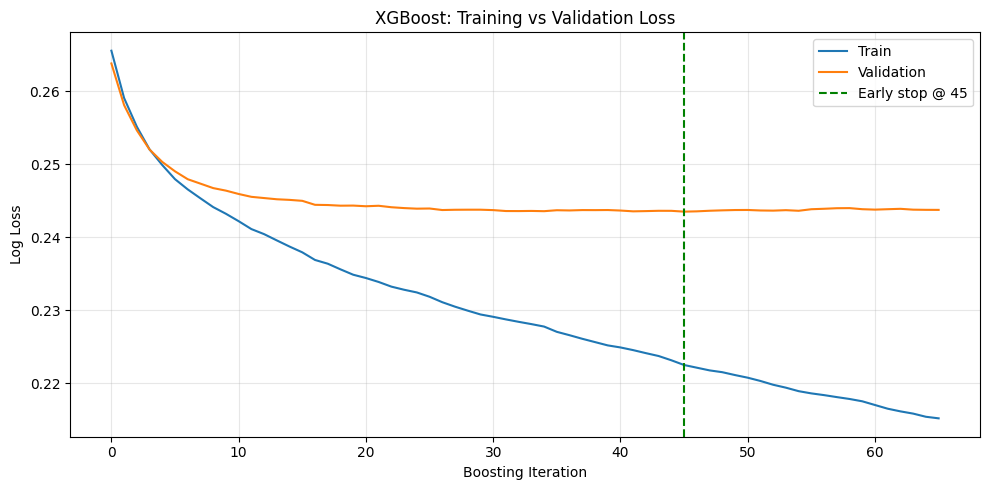

In [22]:
xgb_es = XGBClassifier(n_estimators=500, early_stopping_rounds=20, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_es.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_validation, y_validation)], verbose=False)

results   = xgb_es.evals_result()
best_iter = xgb_es.best_iteration

# Claude:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0']['logloss'], label='Train')
ax.plot(results['validation_1']['logloss'], label='Validation')
ax.axvline(x=best_iter, color='green', linestyle='--', label=f'Early stop @ {best_iter}')
ax.set_xlabel('Boosting Iteration')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost: Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gbdt_loss_curve.png', dpi=150)
plt.show()

#### Feature Importance (plot_importance)

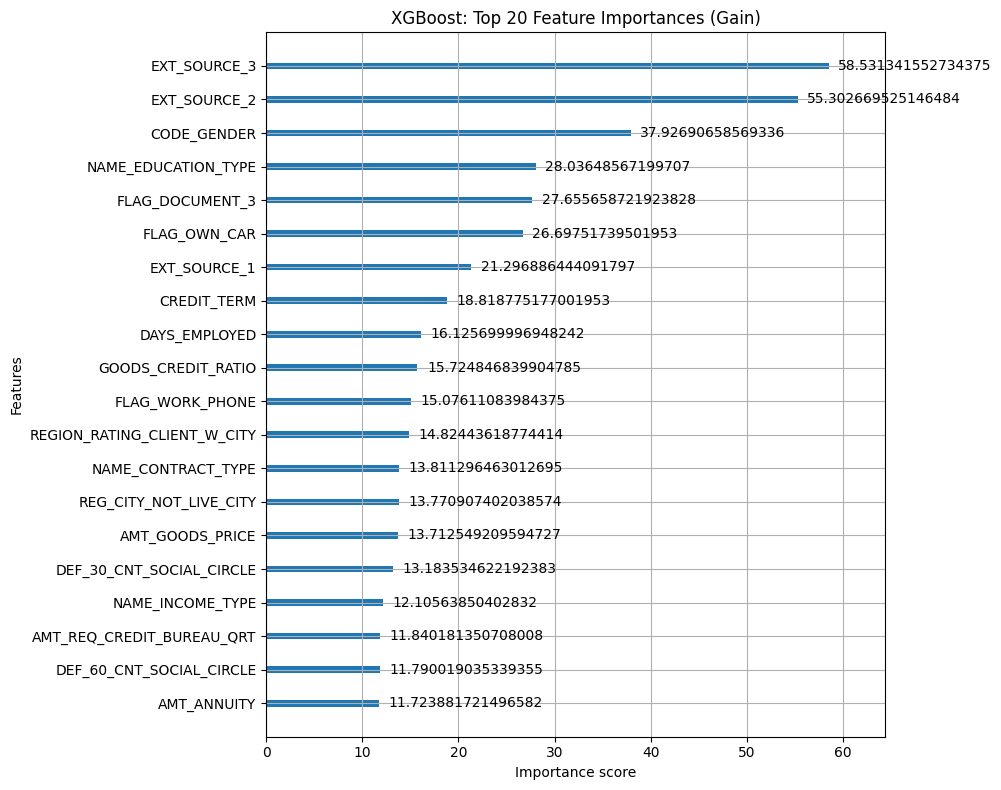

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_es, ax=ax, max_num_features=20, importance_type='gain')
ax.set_title('XGBoost: Top 20 Feature Importances (Gain)')
plt.tight_layout()
plt.savefig('gbdt_feature_importance.png', dpi=150)
plt.show()

#### Effect of Learning Rate: comparing results for at least 3 values (e.g., 0.01, 0.1, 0.3)

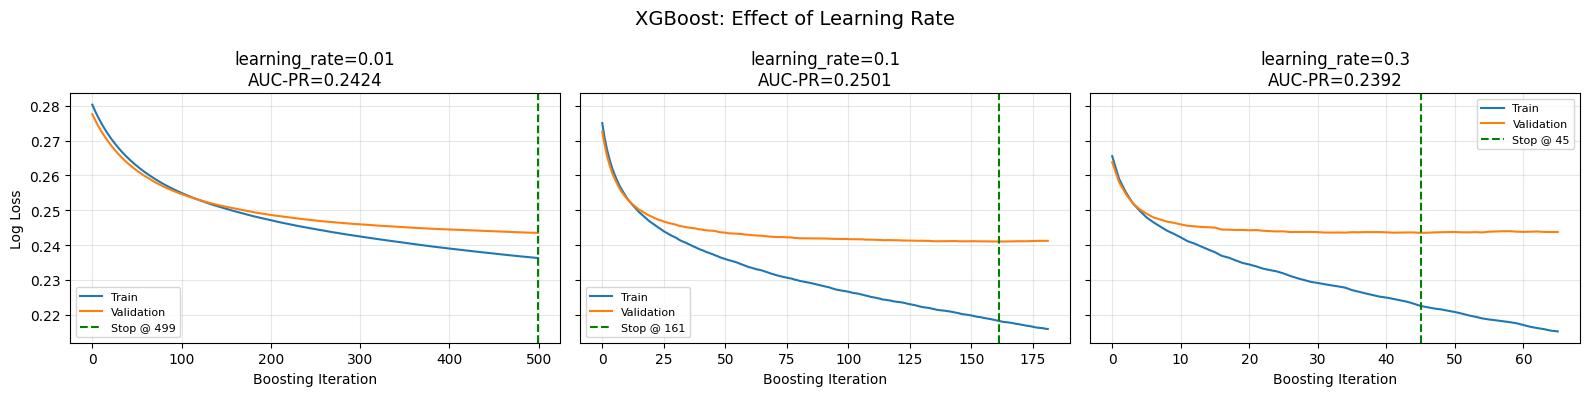

In [24]:
# Claude helped for graphing and helping me debug the for loop over the learning rates, which had some issues
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, lr in zip(axes, [0.01, 0.1, 0.3]):
    m = XGBClassifier(n_estimators=500, learning_rate=lr, early_stopping_rounds=20,
                      eval_metric='logloss', random_state=42, n_jobs=-1)
    m.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_validation, y_validation)],
          verbose=False)
    res = m.evals_result()
    ap  = average_precision_score(y_validation, m.predict_proba(X_validation)[:, 1])
    ax.plot(res['validation_0']['logloss'], label='Train')
    ax.plot(res['validation_1']['logloss'], label='Validation')
    ax.axvline(x=m.best_iteration, color='green', linestyle='--', label=f'Stop @ {m.best_iteration}')
    ax.set_title(f'learning_rate={lr}\nAUC-PR={ap:.4f}')
    ax.set_xlabel('Boosting Iteration')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Log Loss')
plt.suptitle('XGBoost: Effect of Learning Rate', fontsize=14)
plt.tight_layout()
plt.savefig('gbdt_learning_rate.png', dpi=150)
plt.show()

#### Testing The Most Optimal XGB Classifier:

Best iteration: 483


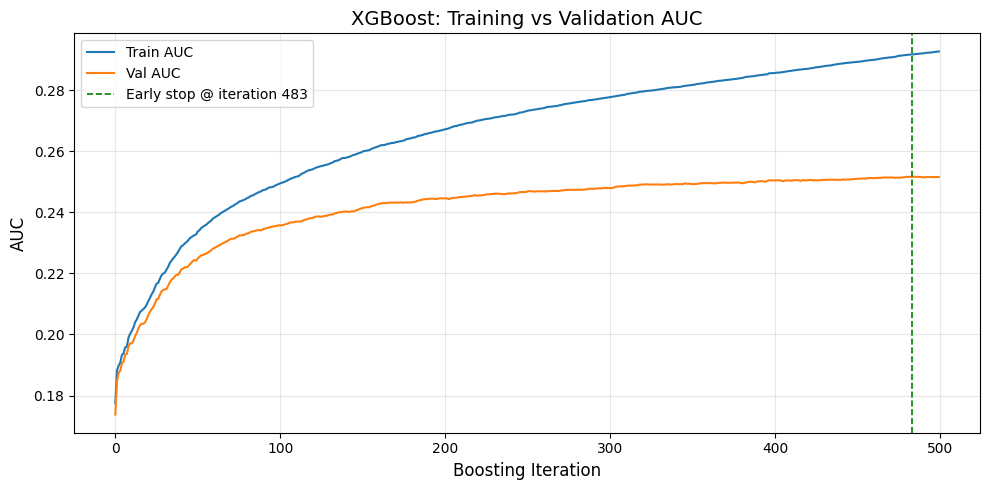

Accuracy : 0.7146
Precision: 0.1724
Recall   : 0.6782
F1       : 0.2749
AUC-PR   : 0.2519


In [25]:
# Note that the above ALL have a low F1 score because it's an unbalanced data. Here, we fix it. Instead of pursuing high accuracy
# and end up with a low F1 score, we try to scale it so that TARGET=1 have higher weight

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos # this is an unbalanced data set, so we need this

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    scale_pos_weight=spw,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

start = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_validation, y_validation)],
    verbose=False
)

gbdt_train_time = time.time() - start

print(f"Best iteration: {xgb_model.best_iteration}")

results = xgb_model.evals_result()
train_loss = results['validation_0']['aucpr']
val_loss   = results['validation_1']['aucpr']
best_iter  = xgb_model.best_iteration

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label='Train AUC', linewidth=1.5)
ax.plot(val_loss,   label='Val AUC',   linewidth=1.5)
ax.axvline(x=best_iter, color='green', linestyle='--', linewidth=1.2,
           label=f'Early stop @ iteration {best_iter}')
ax.set_xlabel('Boosting Iteration', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('XGBoost: Training vs Validation AUC', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gbdt_loss_curve.png', dpi=150)
plt.show()

y_pred  = xgb_model.predict(X_validation)
y_proba = xgb_model.predict_proba(X_validation)[:, 1]
print(f"Accuracy : {accuracy_score(y_validation, y_pred):.4f}")
print(f"Precision: {precision_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"AUC-PR   : {average_precision_score(y_validation, y_proba):.4f}")

### 3. Multi-Layer Perceptron (MLP)

#### Optimal MLP

Accuracy : 0.7101
Precision: 0.1665
Recall   : 0.6575
F1       : 0.2657
AUC-PR   : 0.2243
Epochs   : 17


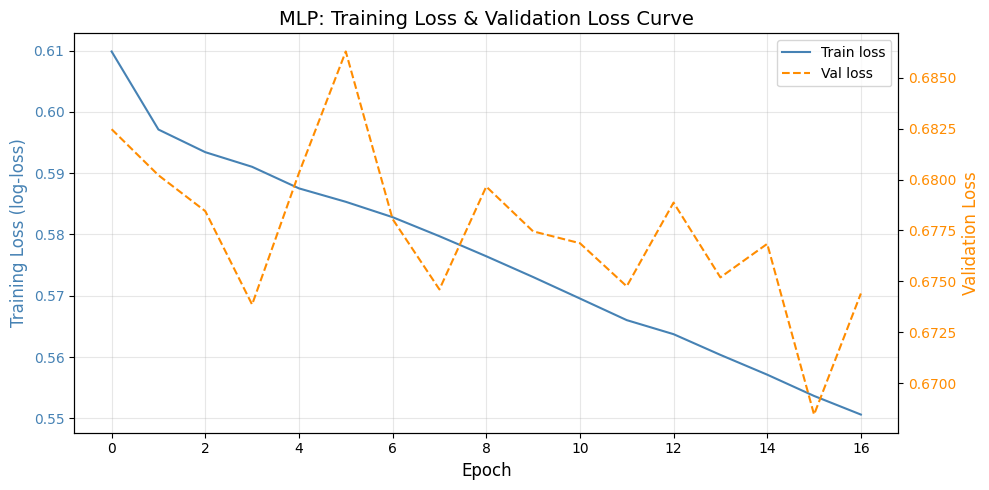

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Note: due to the unbalanced nature of the data set, this is the only one to scale the weights of the target. The next few sections only
# look at the params

sample_weights = compute_sample_weight('balanced', y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.005,
    max_iter=3000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    # n_iter_no_change=200,
)

start = time.time()

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)

mlp_train_time = time.time() - start

y_pred  = mlp.predict(X_validation_scaled)
y_proba = mlp.predict_proba(X_validation_scaled)[:, 1]

# Claude:
print(f"Accuracy : {accuracy_score(y_validation, y_pred):.4f}")
print(f"Precision: {precision_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_validation, y_pred, zero_division=0):.4f}")
print(f"AUC-PR   : {average_precision_score(y_validation, y_proba):.4f}")
print(f"Epochs   : {mlp.n_iter_}")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(mlp.loss_curve_, color='steelblue', linewidth=1.5, label='Train loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss (log-loss)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(mlp.validation_scores_, color='darkorange', linewidth=1.5, linestyle='--', label='Val loss')
ax2.set_ylabel('Validation Loss', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax1.set_title('MLP: Training Loss & Validation Loss Curve', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=150)
plt.show()

#### Parameter Exploration: hidden_layer_sizes (e.g. (64,), (128, 64), (256, 128, 64))

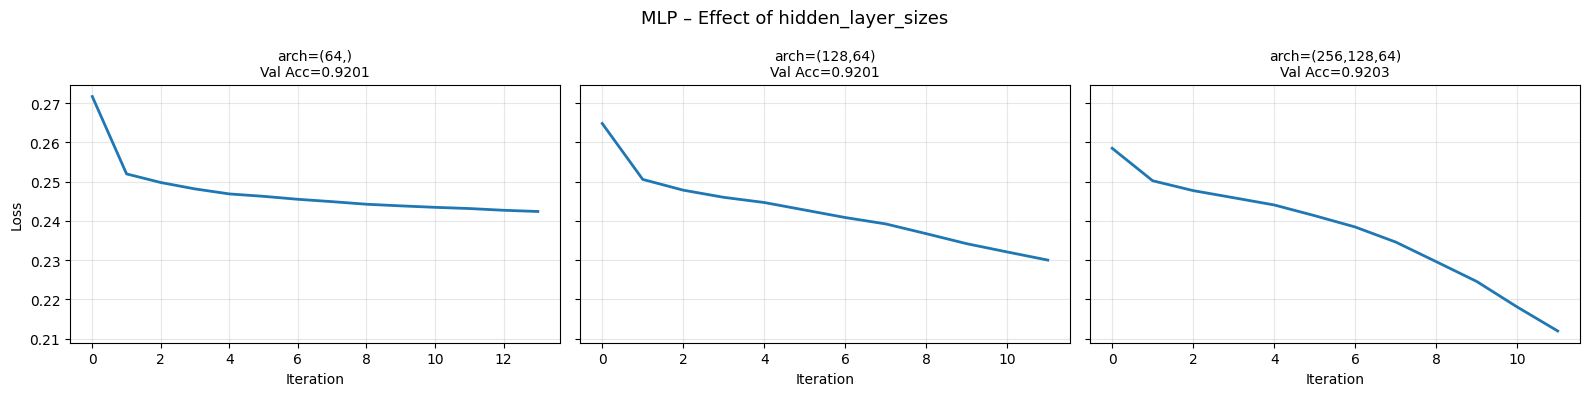

In [27]:
arch_options = [(64,), (128, 64), (256, 128, 64)]
arch_labels  = ["(64,)", "(128,64)", "(256,128,64)"]

# Claude helped me simplify the for loop, I had to debug a bunch of issues myself
fig, axes = plt.subplots(1, len(arch_options), figsize=(16, 4), sharey=True)
for ax, arch, label in zip(axes, arch_options, arch_labels):
    m = MLPClassifier(hidden_layer_sizes=arch, activation="relu",
                      learning_rate_init=0.001, max_iter=200,
                      random_state=42, early_stopping=True,
                      validation_fraction=0.1, n_iter_no_change=10)
    m.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_validation, m.predict(X_validation_scaled))
    ax.plot(m.loss_curve_, linewidth=2)
    ax.set_title(f"arch={label}\nVal Acc={val_acc:.4f}", fontsize=10)
    ax.set_xlabel("Iteration")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
plt.suptitle("MLP – Effect of hidden_layer_sizes", fontsize=13)
plt.tight_layout()
plt.show()

#### Parameter Exploration: activation (e.g., relu vs tanh)

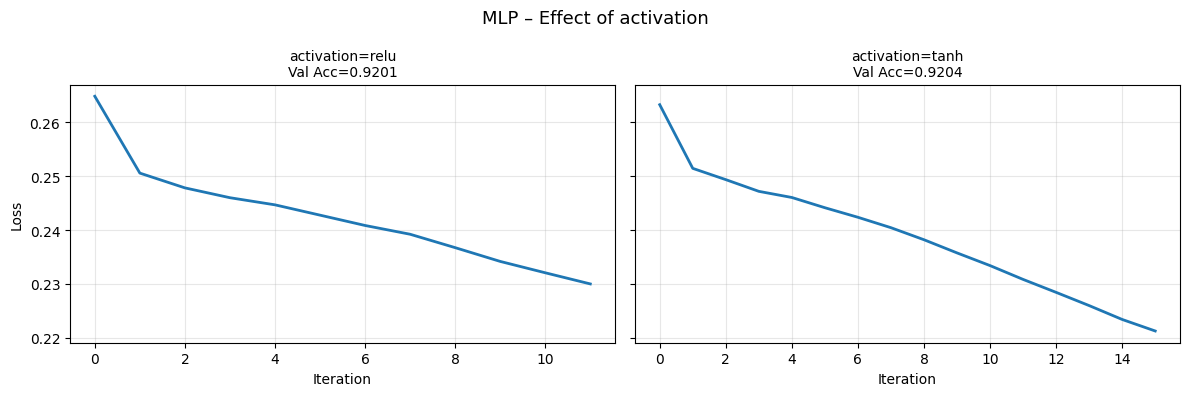

In [28]:
activations = ["relu", "tanh"]
fig, axes = plt.subplots(1, len(activations), figsize=(12, 4), sharey=True)

# Again, Claude helped me with graphing/matplotlib boilerplate (I really dislike graphing)
for ax, act in zip(axes, activations):
    m = MLPClassifier(hidden_layer_sizes=(128, 64), activation=act,
                      learning_rate_init=0.001, max_iter=200,
                      random_state=42, early_stopping=True,
                      validation_fraction=0.1, n_iter_no_change=10)
    m.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_validation, m.predict(X_validation_scaled))
    ax.plot(m.loss_curve_, linewidth=2)
    ax.set_title(f"activation={act}\nVal Acc={val_acc:.4f}", fontsize=10)
    ax.set_xlabel("Iteration")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
plt.suptitle("MLP – Effect of activation", fontsize=13)
plt.tight_layout()
plt.show()

#### Parameter Exploration: learning_rate_init (e.g., 0.001, 0.01, 0.1)

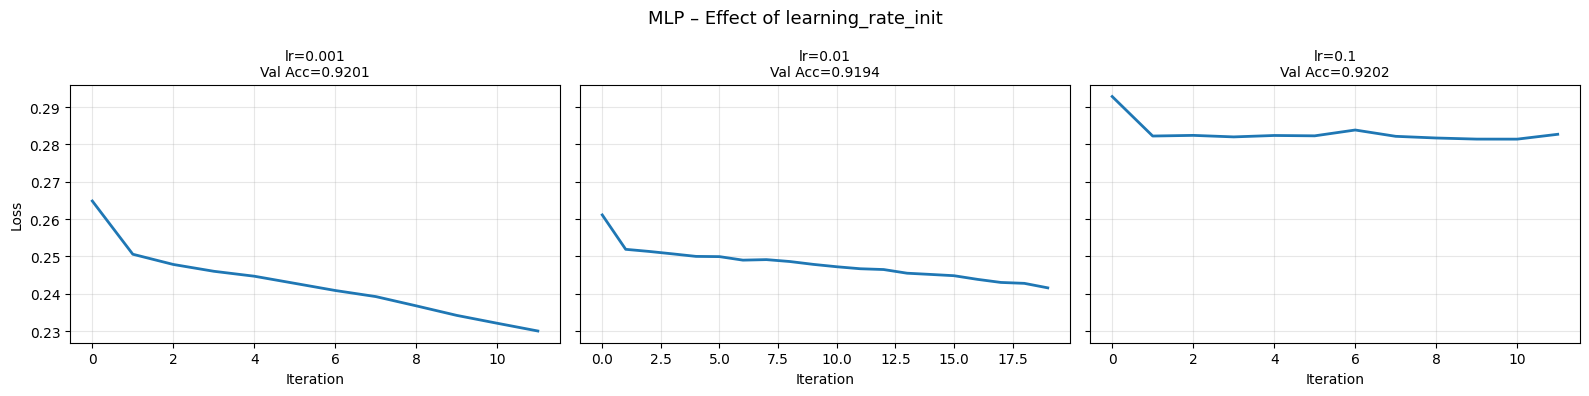

In [29]:
lr_options = [0.001, 0.01, 0.1]
fig, axes = plt.subplots(1, len(lr_options), figsize=(16, 4), sharey=True)

# Claude graphing boilerplate so I didn't have to copy-paste my MLPClassifier over and over again, with me fixing bugs:
for ax, lr in zip(axes, lr_options):
    m = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                      learning_rate_init=lr, max_iter=200,
                      random_state=42, early_stopping=True,
                      validation_fraction=0.1, n_iter_no_change=10)
    m.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_validation, m.predict(X_validation_scaled))
    ax.plot(m.loss_curve_, linewidth=2)
    ax.set_title(f"lr={lr}\nVal Acc={val_acc:.4f}", fontsize=10)
    ax.set_xlabel("Iteration")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
plt.suptitle("MLP – Effect of learning_rate_init", fontsize=13)
plt.tight_layout()
plt.show()

#### Parameter Exploration: max_iter

/opt/anaconda3/envs/machine-learning/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/machine-learning/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/machine-learning/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


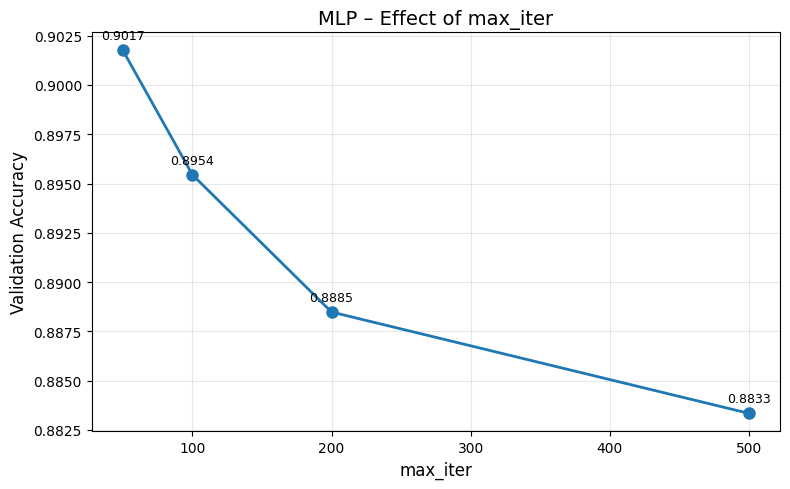

In [34]:
max_iters = [50, 100, 200, 500] # probably won't converge, since learning rate is higher, used here just so the training doesn't go on forever
val_accs  = []

# Claude boilerplate
for mi in max_iters:
    m = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                      learning_rate_init=0.001, max_iter=mi,
                      random_state=42, early_stopping=False)
    m.fit(X_train_scaled, y_train)
    val_accs.append(accuracy_score(y_validation, m.predict(X_validation_scaled)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(max_iters, val_accs, "o-", linewidth=2, markersize=8)
for x, y in zip(max_iters, val_accs):
    ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("max_iter", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("MLP – Effect of max_iter", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. GBDT vs MLP Comparison

In [31]:
# Timing gradient descnet inference time; note that training time was logged earlier under gbdt_train_time
start = time.time()
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
gbdt_inference_time = time.time() - start

# Timing perceptron inference time; note that training time was logged earlier under mlp_train_time
start = time.time()
mlp_preds = mlp.predict(X_test_scaled)
mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]
mlp_inference_time = time.time() - start

# Metrics
metrics = {
    'Model':     ['GBDT (XGBoost)', 'MLP'],
    'Accuracy':  [accuracy_score(y_test, xgb_preds),
                  accuracy_score(y_test, mlp_preds)],
    'Precision': [precision_score(y_test, xgb_preds, zero_division=0),
                  precision_score(y_test, mlp_preds, zero_division=0)],
    'Recall':    [recall_score(y_test, xgb_preds, zero_division=0),
                  recall_score(y_test, mlp_preds, zero_division=0)],
    'F1':        [f1_score(y_test, xgb_preds, zero_division=0),
                  f1_score(y_test, mlp_preds, zero_division=0)],
    'AUC-PR':    [average_precision_score(y_test, xgb_proba),
                  average_precision_score(y_test, mlp_proba)],
    'Train Time (s)': [round(gbdt_train_time, 2), round(mlp_train_time, 2)]
}

df_compare = pd.DataFrame(metrics).set_index('Model')
print(df_compare.to_string())

                Accuracy  Precision    Recall        F1    AUC-PR  Train Time (s)
Model                                                                            
GBDT (XGBoost)  0.714180   0.174183  0.676486  0.277034  0.247175           12.85
MLP             0.706463   0.165370  0.648902  0.263570  0.218233            7.27
